In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [ ]:
full_vbree_results = pd.read_csv("v-bree_mmlupro_test_0_3000_20260306_final.csv")
mmlu_input_raw = pd.read_csv("mmlu_pro_12_cat_250_sample_20260306.csv")

In [3]:
full_vbree_results.describe()

,Unnamed: 0,id,iteration,prompt_tokens,response_tokens,score,score_moving_avg,score_moving_variance,confidence_score
count,57696.000000,57696.000000,57696.000000,57696.000000,57696.000000,5.469500e+04,4.869300e+04,4.869300e+04,4.869300e+04
mean,28850.795133,6368.783226,12.070733,508.294353,309.712389,1.956303e+11,2.197441e+11,2.351262e+27,3.285923e+04
std,16660.323126,3941.205583,9.149597,197.570477,588.488698,4.575199e+13,2.799503e+13,2.995468e+29,1.812424e+06
min,0.000000,73.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,14423.750000,2716.000000,4.000000,405.000000,72.000000,7.500000e+01,6.833333e+01,6.300000e+01,1.526718e-02
50%,28847.500000,7036.000000,10.000000,487.000000,131.000000,8.500000e+01,8.500000e+01,1.750000e+02,1.153830e-01
75%,43271.250000,10475.000000,18.000000,605.000000,377.000000,9.600000e+01,9.000000e+01,1.008333e+03,3.785743e-01
max,57729.000000,12254.000000,44.000000,5094.000000,7822.000000,1.070000e+16,3.566667e+15,3.816333e+31,1.000000e+08


In [4]:
full_vbree_results.head(1)

,Unnamed: 0,id,iteration,model,question,choices,domain,prompt_tokens,previous_answer,updated_answer,selected_choice,response_tokens,scoring_model,score,score_moving_avg,score_moving_variance,chosen_response,confidence_score
0,0,3206,0,openai/gpt-oss-20b:groq,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,407,NaN,The statement that the same X chromosome is in...,B,685,Qwen/Qwen2.5-7B-Instruct:together,65.0,NaN,NaN,False,NaN


In [5]:
mmlu_input_raw.head(1)

,question_id,question,options,answer,answer_index,cot_content,category,src
0,3206,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",B,1,NaN,biology,ori_mmlu-high_school_biology


In [6]:
if "true_answer" not in full_vbree_results.columns:
    full_vbree_results = full_vbree_results.merge(
        mmlu_input_raw[["answer", "question_id", "category"]], 
        left_on="id", 
        right_on = "question_id",
        how="left"
    )

    full_vbree_results.rename(
        columns={"answer":"true_answer", "selected_choice":"selected_answer"}, 
        inplace=True
        )

    full_vbree_results.drop("question_id", inplace=True, axis=1)
    print("True answer successfully merged.")
else:
    print("True answer could not be merged.")

full_vbree_results["correct_selection"] = full_vbree_results["selected_answer"] == full_vbree_results["true_answer"]

True answer successfully merged.


In [7]:
first_answers = full_vbree_results[full_vbree_results["iteration"] == 0]
selected_answers = full_vbree_results[full_vbree_results["chosen_response"] == True]
# SAVE FOR BERTSCORING
#starter = first_answers["updated_answer"].tolist()
#submitted = selected_answers["updated_answer"].tolist()


In [8]:
full_vbree_results.head(1)

,Unnamed: 0,id,iteration,model,question,choices,domain,prompt_tokens,previous_answer,updated_answer,...,response_tokens,scoring_model,score,score_moving_avg,score_moving_variance,chosen_response,confidence_score,true_answer,category,correct_selection
0,0,3206,0,openai/gpt-oss-20b:groq,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,407,NaN,The statement that the same X chromosome is in...,...,685,Qwen/Qwen2.5-7B-Instruct:together,65.0,NaN,NaN,False,NaN,B,biology,True


In [9]:
def get_cat_corr(df, independent_variable, grouping):
    return df.groupby(grouping).apply(
        lambda x: x[independent_variable].corr(x['correct_selection'])
    )

selected_iteration_correlation = get_cat_corr(selected_answers, "iteration", "category")
full_iteration_correlation = get_cat_corr(full_vbree_results, "iteration", "category")

iteration_comparison = pd.concat([selected_iteration_correlation, full_iteration_correlation], axis=1)
iteration_comparison.columns = ['selected_answers', 'whole_process']
print("Iteration Correlation With Correct Selection\n")
print(iteration_comparison)

Iteration Correlation With Correct Selection

                  selected_answers  whole_process
category                                         
biology                   0.001520       0.070279
business                 -0.013551      -0.040887
chemistry                 0.082613       0.024496
computer science         -0.069276       0.018117
economics                -0.009333      -0.000515
engineering               0.066865      -0.018126
history                  -0.140467      -0.032823
law                      -0.038707      -0.069499
math                     -0.061679      -0.019859
philosophy               -0.113700      -0.045964
physics                  -0.057559      -0.067071
psychology               -0.098872      -0.027606


C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(
C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(


In [10]:
selected_confidence_correlation = get_cat_corr(selected_answers, "confidence_score", "category")
full_confidence_correlation = get_cat_corr(full_vbree_results, "confidence_score", "category")

confidence_comparison = pd.concat([selected_confidence_correlation, selected_confidence_correlation], axis=1)
confidence_comparison.columns = ['selected_answers', 'whole_process']

print("Confidence Score Correlation With Correct Selection\n")
print(confidence_comparison)

Confidence Score Correlation With Correct Selection

                  selected_answers  whole_process
category                                         
biology                  -0.129837      -0.129837
business                 -0.026993      -0.026993
chemistry                 0.186778       0.186778
computer science          0.043074       0.043074
economics                -0.083672      -0.083672
engineering               0.166839       0.166839
history                   0.036377       0.036377
law                      -0.039128      -0.039128
math                      0.069152       0.069152
philosophy                0.061739       0.061739
physics                   0.175762       0.175762
psychology                0.061039       0.061039


C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(
C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(


In [11]:
selected_token_correlation = get_cat_corr(selected_answers, "response_tokens", "category")
full_token_correlation = get_cat_corr(full_vbree_results, "response_tokens", "category")

token_comparison = pd.concat([selected_token_correlation, full_token_correlation], axis=1)
token_comparison.columns = ['selected_answers', 'whole_process']

print("Token Count Correlation With Correct Selection\n")
print(token_comparison)

Token Count Correlation With Correct Selection

                  selected_answers  whole_process
category                                         
biology                  -0.182965       0.004674
business                 -0.081698      -0.106676
chemistry                -0.142052      -0.075545
computer science          0.007000      -0.079005
economics                -0.130132      -0.077870
engineering              -0.040951      -0.019584
history                  -0.101417      -0.075849
law                      -0.089028      -0.039584
math                      0.154927      -0.183280
philosophy               -0.081863      -0.027037
physics                  -0.080832      -0.089981
psychology               -0.041664      -0.051017


C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(
C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(


In [12]:
selected_variance_correlation = get_cat_corr(selected_answers, "score_moving_variance", "category")

print("Variance Correlation With Correct Selection\n")
print(selected_variance_correlation)

Variance Correlation With Correct Selection

category
biology             0.077794
business           -0.058883
chemistry          -0.095304
computer science   -0.030332
economics          -0.083119
engineering        -0.152760
history             0.030013
law                -0.100340
math               -0.116018
philosophy          0.024301
physics            -0.225952
psychology         -0.021730
dtype: float64


C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(


In [13]:
selected_model_confidence_correlation = get_cat_corr(selected_answers, "confidence_score", "model")
full_model_confidence_correlation = get_cat_corr(full_vbree_results, "confidence_score", "model")

model_comparison = pd.concat([selected_model_confidence_correlation, full_model_confidence_correlation], axis=1)
model_comparison.columns = ['selected_answers', 'whole_process']

print("Correct Answer Correlation With Confidence Score By Model\n")
print(model_comparison)

Correct Answer Correlation With Confidence Score By Model

                                           selected_answers  whole_process
model                                                                     
Qwen/Qwen2.5-7B-Instruct:together                  0.025194       0.008760
meta-llama/Llama-3.1-8B-Instruct:cerebras          0.039488       0.011467
openai/gpt-oss-20b:groq                            0.015073       0.004139


C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(
C:\Users\jecgr\AppData\Local\Temp\ipykernel_25668\1501439631.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grouping).apply(


In [14]:
comparison_mean = pd.concat([
    full_vbree_results.groupby('model')['correct_selection'].mean(),
    first_answers.groupby('model')['correct_selection'].mean(),
    selected_answers.groupby('model')['correct_selection'].mean()
], axis=1)
comparison_mean.columns = ['all_answers', 'initial', 'selected']


total_row = pd.DataFrame([{
    "all_answers":full_vbree_results['correct_selection'].mean(),
    "initial": first_answers['correct_selection'].mean(),
    "selected":selected_answers['correct_selection'].mean()
    }], index=["V-BReE Total"])

comparison_mean= pd.concat([comparison_mean, total_row])

print("Likelihood Of Selecting A Correct Answer\n")
print(comparison_mean)

Likelihood Of Selecting A Correct Answer

                                           all_answers   initial  selected
Qwen/Qwen2.5-7B-Instruct:together             0.605434  0.489968  0.661526
meta-llama/Llama-3.1-8B-Instruct:cerebras     0.570259  0.370937  0.629991
openai/gpt-oss-20b:groq                       0.620245  0.624008  0.646417
V-BReE Total                                  0.598620  0.493502  0.646451


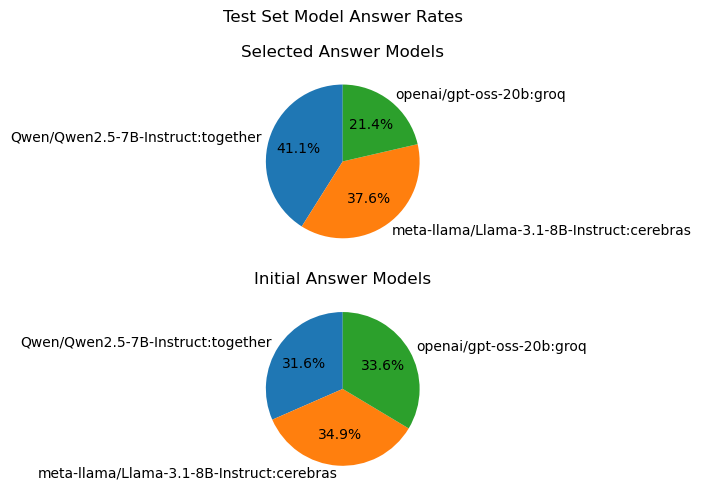

In [15]:
selected_model = selected_answers['model'].value_counts()/len(selected_answers)
first_model = first_answers['model'].value_counts()/len(selected_answers)

models = pd.concat([selected_model, first_model], axis=1)
models.columns=["selected_model", "initial_model"]

sizes1 = models["selected_model"].values
sizes2 = models["initial_model"].values
labels = models.index

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

ax1.pie(sizes1, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.set_title('Selected Answer Models')

ax2.pie(sizes2, labels=labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Initial Answer Models')

plt.suptitle("Test Set Model Answer Rates")

plt.tight_layout()
plt.show()

In [16]:
wrong_to_right = 0
right_to_wrong = 0
wrong_to_wrong = 0

for i in range(len(first_answers)):
    was_correct = first_answers["correct_selection"].iloc[i]
    is_correct = selected_answers["correct_selection"].iloc[i]
    
    if not was_correct and is_correct:
        wrong_to_right += 1
    elif was_correct and not is_correct:
        right_to_wrong += 1
    elif not was_correct and not is_correct and first_answers["selected_answer"].iloc[i] != selected_answers["selected_answer"].iloc[i]:
        wrong_to_wrong += 1

print(
    f"Conversion Rates:\nWrong to right: {wrong_to_right/len(first_answers)*100:.2f}%\n"+
    f"Right to wrong: {right_to_wrong/len(first_answers)*100:.2f}%\n"+
    f"Wrong to wrong: {wrong_to_wrong/len(first_answers)*100:.2f}%"
    )

Conversion Rates:
Wrong to right: 19.69%
Right to wrong: 4.40%
Wrong to wrong: 13.63%


In [17]:
wrong_to_right = 0
right_to_wrong = 0
wrong_to_wrong = 0

first_answers_chatGPT = first_answers[first_answers['model'] == "openai/gpt-oss-20b:groq"]
selected_answers_chatGPT_started = selected_answers[selected_answers["question"].isin(first_answers_chatGPT["question"])]
for i in range(len(first_answers_chatGPT)):
    was_correct = first_answers_chatGPT["correct_selection"].iloc[i]
    is_correct = selected_answers_chatGPT_started["correct_selection"].iloc[i]
    
    if not was_correct and is_correct:
        wrong_to_right += 1
    elif was_correct and not is_correct:
        right_to_wrong += 1
    elif not was_correct and not is_correct and first_answers["selected_answer"].iloc[i] != selected_answers["selected_answer"].iloc[i]:
        wrong_to_wrong += 1

print(
    f"Conversion Rates:\nWrong to right: {wrong_to_right/len(first_answers)*100:.2f}%\n"+
    f"Right to wrong: {right_to_wrong/len(first_answers)*100:.2f}%\n"+
    f"Wrong to wrong: {wrong_to_wrong/len(first_answers)*100:.2f}%"
    )

Conversion Rates:
Wrong to right: 6.93%
Right to wrong: 6.43%
Wrong to wrong: 2.27%


In [19]:
print(f"Average iterations to submission: {selected_answers["iteration"].mean():.1f}")

Average iterations to submission: 10.0


In [20]:
print(f"Standard deviation of iterations to submission: {selected_answers["iteration"].std():.1f}")

Standard deviation of iterations to submission: 7.5
